<a href="https://colab.research.google.com/github/ashley241013006160-sudo/AI-ML-Lab/blob/main/AshLab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install network matplotlib

Graph (Adjacency List Representation):
  A: ['B', 'C']
  B: ['D', 'E']
  C: ['F']
  D: []
  E: []
  F: []


BFS Traversal Order: A, B, C, D, E, F

DFS Traversal Order: A, B, D, E, C, F



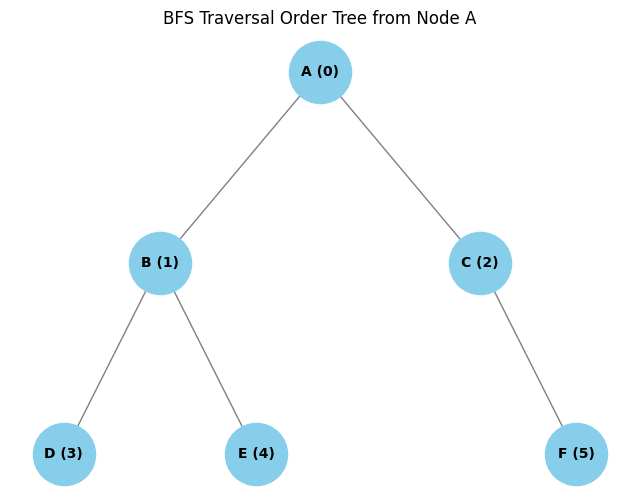

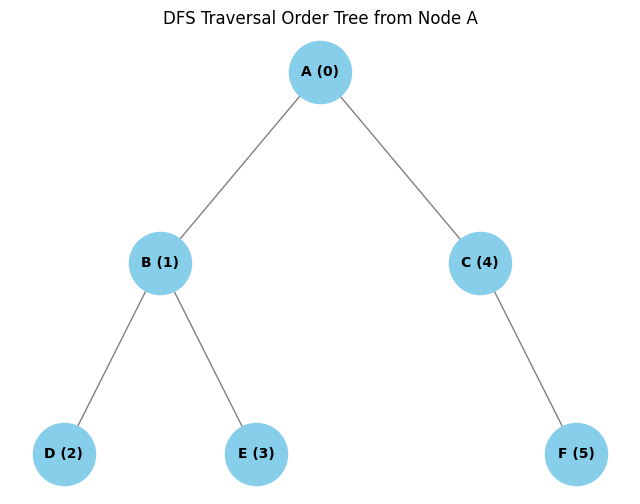

In [3]:
import collections
import networkx as nx
import matplotlib.pyplot as plt

# 1. Store the graph using an adjacency list (a Python dictionary).
# Assumed tree structure:
# A is the root.
# A connects to B and C.
# B connects to D and E.
# C connects to F.
# This forms a tree with 6 nodes (A, B, C, D, E, F).
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': [],
    'F': []
}

print("Graph (Adjacency List Representation):")
for node, neighbors in graph.items():
    print(f"  {node}: {neighbors}")
print("\n")

def bfs(graph, start_node):
    """Performs a Breadth-First Search (BFS) traversal of the graph."""
    visited_order_map = {} # Stores node and its discovery order (node: index)
    queue = collections.deque([start_node])
    order = [] # List of nodes in BFS traversal order
    bfs_spanning_edges = [] # Edges forming the BFS spanning tree
    discovery_index = 0

    # Mark the start node as visited and add to order
    visited_order_map[start_node] = discovery_index
    order.append(start_node)
    discovery_index += 1

    while queue:
        current_node = queue.popleft()

        # Explore neighbors
        for neighbor in graph.get(current_node, []):
            if neighbor not in visited_order_map:
                visited_order_map[neighbor] = discovery_index
                order.append(neighbor)
                queue.append(neighbor)
                bfs_spanning_edges.append((current_node, neighbor))
                discovery_index += 1
    return order, bfs_spanning_edges, visited_order_map

def dfs(graph, start_node):
    """Performs a Depth-First Search (DFS) traversal of the graph."""
    visited_order_map = {} # Stores node and its discovery order (node: index)
    stack = [start_node]
    order = [] # List of nodes in DFS traversal order
    dfs_spanning_edges = [] # Edges forming the DFS spanning tree
    discovery_index = 0

    while stack:
        current_node = stack.pop() # LIFO for DFS

        if current_node not in visited_order_map:
            visited_order_map[current_node] = discovery_index
            order.append(current_node)
            discovery_index += 1

            # Push neighbors onto stack in reverse order to ensure a consistent
            # processing order (e.g., alphabetical, if applicable) when popped.
            # This creates the DFS spanning tree edges.
            for neighbor in sorted(graph.get(current_node, []), reverse=True):
                if neighbor not in visited_order_map: # Only add unvisited neighbors to stack
                    stack.append(neighbor)
                    # Add edge when neighbor is 'discovered' from current_node
                    dfs_spanning_edges.append((current_node, neighbor))

    return order, dfs_spanning_edges, visited_order_map

# 2. Perform a BFS traversal starting from node A.
bfs_order, bfs_spanning_edges, bfs_visited_order_map = bfs(graph, 'A')

# 3. Perform a DFS traversal starting from node A.
dfs_order, dfs_spanning_edges, dfs_visited_order_map = dfs(graph, 'A')

# 4. Prints both traversal orders
print(f"BFS Traversal Order: {', '.join(bfs_order)}\n")
print(f"DFS Traversal Order: {', '.join(dfs_order)}\n")

# 5. Draws two separate tree diagrams

def draw_traversal_tree(title, edges, visited_order_map, original_graph_nodes, node_positions=None):
    """Draws a tree diagram showing the traversal order."""
    G = nx.DiGraph() # Directed graph for traversal visualization
    G.add_edges_from(edges)

    # Add all nodes from the original graph, even if they have no outgoing traversal edges
    for node in original_graph_nodes:
        if node not in G.nodes():
            G.add_node(node)

    # Create labels for nodes, showing their original name and discovery order
    node_labels = {node: f"{node} ({visited_order_map.get(node, '-')})" for node in G.nodes()}

    plt.figure(figsize=(8, 6))
    plt.title(title)

    # Define fixed positions for the nodes to ensure a consistent and readable tree layout.
    # These positions are tailored for the assumed tree structure (A->B,C; B->D,E; C->F).
    if node_positions is None:
        # Default positions if not provided
        pos = {
            'A': (0.5, 1.0),
            'B': (0.25, 0.6), 'C': (0.75, 0.6),
            'D': (0.1, 0.2), 'E': (0.4, 0.2), 'F': (0.9, 0.2)
        }
    else:
        pos = node_positions

    nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=2000)
    nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, arrowsize=20)
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=10, font_weight='bold')
    plt.axis('off') # Hide axes
    plt.show()

# Define fixed positions for the nodes to ensure consistent tree-like layout for both plots
# This makes the diagrams easier to compare and understand.
fixed_node_positions = {
    'A': (0.5, 1.0),
    'B': (0.25, 0.6), 'C': (0.75, 0.6),
    'D': (0.1, 0.2), 'E': (0.4, 0.2), 'F': (0.9, 0.2)
}

draw_traversal_tree("BFS Traversal Order Tree from Node A", bfs_spanning_edges, bfs_visited_order_map, graph.keys(), fixed_node_positions)
draw_traversal_tree("DFS Traversal Order Tree from Node A", dfs_spanning_edges, dfs_visited_order_map, graph.keys(), fixed_node_positions)